In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# make plots visible
%matplotlib inline


In [2]:
import os
os.listdir("../data")

['Sample - Superstore.csv', 'superstore_new.csv']

In [3]:
df = pd.read_csv("../data/superstore_new.csv", encoding="latin1")

In [4]:
df = pd.read_csv("../data/superstore_new.csv", encoding="cp1252")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.columns  


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.head()
df.info()
df.columns
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

np.int64(0)

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [11]:
df["Order Date"].dtype

dtype('<M8[ns]')

In [12]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

In [13]:
daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [14]:
daily_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  1237 non-null   datetime64[ns]
 1   Sales       1237 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.5 KB


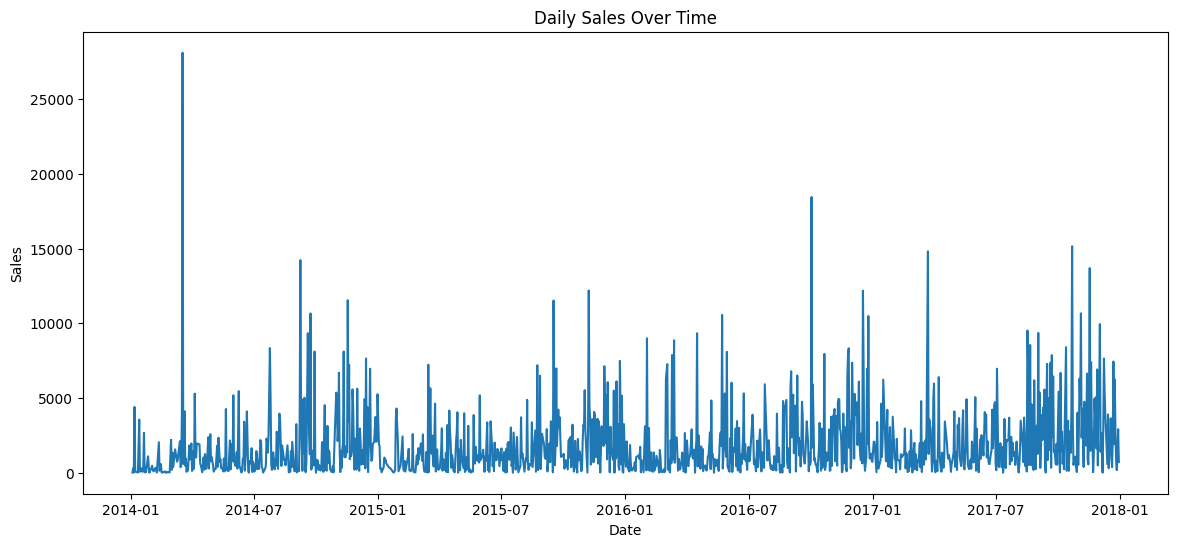

In [15]:
plt.figure(figsize=(14,6))
plt.plot(daily_sales["Order Date"], daily_sales["Sales"])
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [16]:
daily_sales["year"] = daily_sales["Order Date"].dt.year
daily_sales["month"] = daily_sales["Order Date"].dt.month
daily_sales["day"] = daily_sales["Order Date"].dt.day
daily_sales["weekday"] = daily_sales["Order Date"].dt.weekday
daily_sales["quarter"] = daily_sales["Order Date"].dt.quarter

In [17]:
daily_sales.head()

,Order Date,Sales,year,month,day,weekday,quarter
0,2014-01-03,16.448,2014,1,3,4,1
1,2014-01-04,288.060,2014,1,4,5,1
2,2014-01-05,19.536,2014,1,5,6,1
3,2014-01-06,4407.100,2014,1,6,0,1
4,2014-01-07,87.158,2014,1,7,1,1


In [18]:
daily_sales["lag_1"] = daily_sales["Sales"].shift(1)
daily_sales["lag_7"] = daily_sales["Sales"].shift(7)
daily_sales["rolling_mean_7"] = daily_sales["Sales"].rolling(window=7).mean()

daily_sales.head(10)

,Order Date,Sales,year,month,day,weekday,quarter,lag_1,lag_7,rolling_mean_7
0,2014-01-03,16.448,2014,1,3,4,1,NaN,NaN,NaN
1,2014-01-04,288.060,2014,1,4,5,1,16.448,NaN,NaN
2,2014-01-05,19.536,2014,1,5,6,1,288.060,NaN,NaN
3,2014-01-06,4407.100,2014,1,6,0,1,19.536,NaN,NaN
4,2014-01-07,87.158,2014,1,7,1,1,4407.100,NaN,NaN
5,2014-01-09,40.544,2014,1,9,3,1,87.158,NaN,NaN
6,2014-01-10,54.830,2014,1,10,4,1,40.544,NaN,701.953714
7,2014-01-11,9.940,2014,1,11,5,1,54.830,16.448,701.024000
8,2014-01-13,3553.795,2014,1,13,0,1,9.940,288.060,1167.557571
9,2014-01-14,61.960,2014,1,14,1,1,3553.795,19.536,1173.618143


In [19]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales = daily_sales.set_index("Order Date")
daily_sales = daily_sales.asfreq("D", fill_value=0)
daily_sales = daily_sales.reset_index()

daily_sales.head(10)

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158
5,2014-01-08,0.000
6,2014-01-09,40.544
7,2014-01-10,54.830
8,2014-01-11,9.940
9,2014-01-12,0.000


In [20]:
daily_sales["year"] = daily_sales["Order Date"].dt.year
daily_sales["month"] = daily_sales["Order Date"].dt.month
daily_sales["day"] = daily_sales["Order Date"].dt.day
daily_sales["weekday"] = daily_sales["Order Date"].dt.weekday
daily_sales["quarter"] = daily_sales["Order Date"].dt.quarter

daily_sales["lag_1"] = daily_sales["Sales"].shift(1)
daily_sales["lag_7"] = daily_sales["Sales"].shift(7)
daily_sales["rolling_mean_7"] = daily_sales["Sales"].rolling(window=7).mean()

In [21]:
daily_sales.head(12)

,Order Date,Sales,year,month,day,weekday,quarter,lag_1,lag_7,rolling_mean_7
0,2014-01-03,16.448,2014,1,3,4,1,NaN,NaN,NaN
1,2014-01-04,288.060,2014,1,4,5,1,16.448,NaN,NaN
2,2014-01-05,19.536,2014,1,5,6,1,288.060,NaN,NaN
3,2014-01-06,4407.100,2014,1,6,0,1,19.536,NaN,NaN
4,2014-01-07,87.158,2014,1,7,1,1,4407.100,NaN,NaN
5,2014-01-08,0.000,2014,1,8,2,1,87.158,NaN,NaN
6,2014-01-09,40.544,2014,1,9,3,1,0.000,NaN,694.120857
7,2014-01-10,54.830,2014,1,10,4,1,40.544,16.448,699.604000
8,2014-01-11,9.940,2014,1,11,5,1,54.830,288.060,659.872571
9,2014-01-12,0.000,2014,1,12,6,1,9.940,19.536,657.081714


In [22]:
daily_sales = daily_sales.dropna()

In [23]:
daily_sales.isnull().sum()

Order Date        0
Sales             0
year              0
month             0
day               0
weekday           0
quarter           0
lag_1             0
lag_7             0
rolling_mean_7    0
dtype: int64

In [24]:
features = ["year", "month", "day", "weekday", "quarter",
            "lag_1", "lag_7", "rolling_mean_7"]

X = daily_sales[features]
y = daily_sales["Sales"]

In [25]:
split_index = int(len(daily_sales) * 0.8)
#80% for training, 20% for testing

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [26]:
X_train.shape
X_test.shape

(291, 8)

In [27]:
X_train.shape
X_test.shape
len(daily_sales)

1451

In [28]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred = model.predict(X_test)

In [30]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1721.4279501305837
RMSE: 2385.097434994093
R² Score: 0.10499326694540534


In [31]:
daily_sales["lag_14"] = daily_sales["Sales"].shift(14)
daily_sales["lag_30"] = daily_sales["Sales"].shift(30)

daily_sales["rolling_mean_14"] = daily_sales["Sales"].rolling(14).mean()
daily_sales["rolling_mean_30"] = daily_sales["Sales"].rolling(30).mean()

daily_sales["is_weekend"] = daily_sales["weekday"].apply(lambda x: 1 if x >= 5 else 0)

In [32]:
daily_sales = daily_sales.dropna()

In [33]:
features = [
    "year",
    "month",
    "day",
    "weekday",
    "quarter",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "is_weekend"
]

X = daily_sales[features]
y = daily_sales["Sales"]

In [34]:
split_index = int(len(daily_sales) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [35]:
X_train.shape
X_test.shape

(285, 13)

In [36]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Improved MAE:", mae)
print("Improved RMSE:", rmse)
print("Improved R²:", r2)

Improved MAE: 1714.7927550263157
Improved RMSE: 2315.2854166700113
Improved R²: 0.16886762906871877


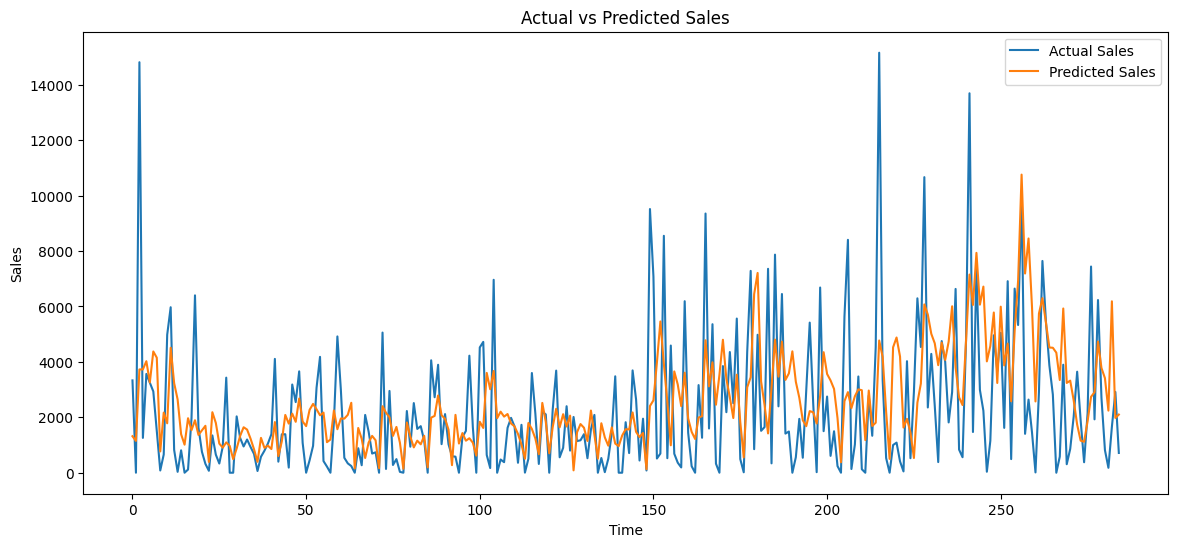

In [38]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [39]:
last_date = daily_sales["Order Date"].max()
last_date

Timestamp('2017-12-30 00:00:00')

In [40]:
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_dates

DatetimeIndex(['2017-12-31', '2018-01-01', '2018-01-02', '2018-01-03',
               '2018-01-04', '2018-01-05', '2018-01-06', '2018-01-07',
               '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
               '2018-01-12', '2018-01-13', '2018-01-14', '2018-01-15',
               '2018-01-16', '2018-01-17', '2018-01-18', '2018-01-19',
               '2018-01-20', '2018-01-21', '2018-01-22', '2018-01-23',
               '2018-01-24', '2018-01-25', '2018-01-26', '2018-01-27',
               '2018-01-28', '2018-01-29'],
              dtype='datetime64[ns]', freq='D')

In [41]:
future_predictions = []

sales_history = daily_sales["Sales"].tolist()

for date in future_dates:
    
    lag_1 = sales_history[-1]
    lag_7 = sales_history[-7]
    lag_14 = sales_history[-14]
    lag_30 = sales_history[-30]

    rolling_mean_7 = np.mean(sales_history[-7:])
    rolling_mean_14 = np.mean(sales_history[-14:])
    rolling_mean_30 = np.mean(sales_history[-30:])

    is_weekend = 1 if date.weekday() >= 5 else 0

    future_row = pd.DataFrame({
        "year": [date.year],
        "month": [date.month],
        "day": [date.day],
        "weekday": [date.weekday()],
        "quarter": [date.quarter],
        "lag_1": [lag_1],
        "lag_7": [lag_7],
        "lag_14": [lag_14],
        "lag_30": [lag_30],
        "rolling_mean_7": [rolling_mean_7],
        "rolling_mean_14": [rolling_mean_14],
        "rolling_mean_30": [rolling_mean_30],
        "is_weekend": [is_weekend]
    })

    pred = model.predict(future_row)[0]

    future_predictions.append(pred)

    sales_history.append(pred)

In [42]:
future_predictions[:10]

[np.float64(2049.589086999999),
 np.float64(2494.126646499999),
 np.float64(1338.4797619999988),
 np.float64(1185.7249265),
 np.float64(1111.7396884999994),
 np.float64(2017.0798339999985),
 np.float64(1389.9704099999997),
 np.float64(2035.1374170000004),
 np.float64(2242.3059584999996),
 np.float64(1844.8316179999988)]

In [43]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted Sales": future_predictions
})

forecast_df.head(10)

,Date,Predicted Sales
0,2017-12-31,2049.589087
1,2018-01-01,2494.126646
2,2018-01-02,1338.479762
3,2018-01-03,1185.724927
4,2018-01-04,1111.739688
5,2018-01-05,2017.079834
6,2018-01-06,1389.970410
7,2018-01-07,2035.137417
8,2018-01-08,2242.305958
9,2018-01-09,1844.831618


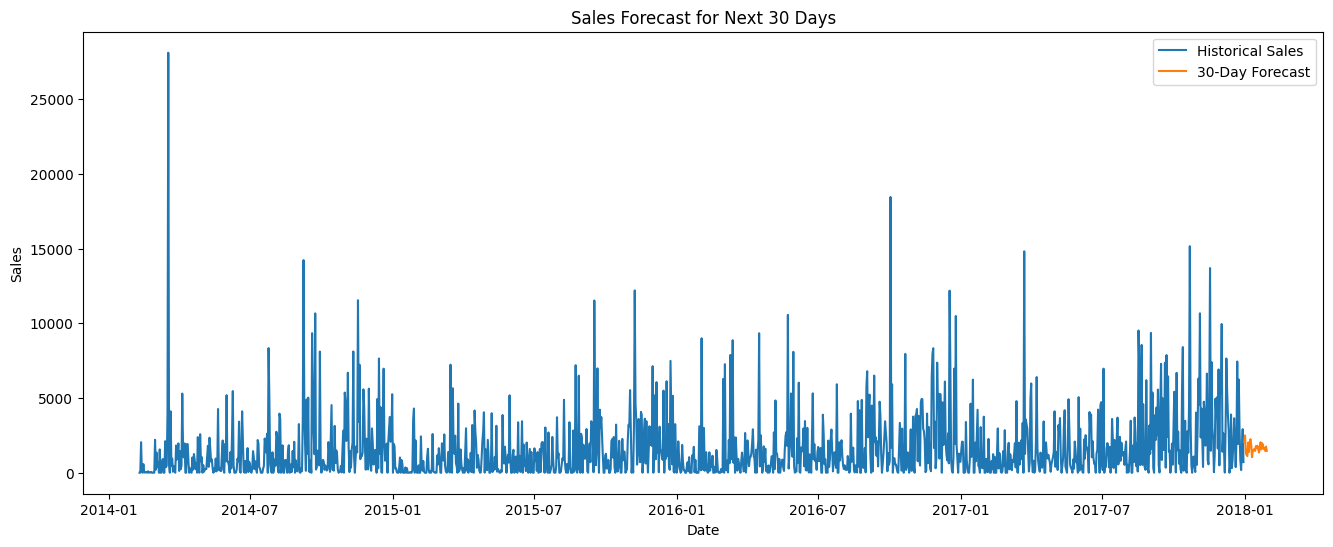

In [44]:
plt.figure(figsize=(16,6))

plt.plot(daily_sales["Order Date"], daily_sales["Sales"], label="Historical Sales")

plt.plot(forecast_df["Date"], forecast_df["Predicted Sales"],
         label="30-Day Forecast")

plt.title("Sales Forecast for Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [45]:
forecast_df.to_csv("../outputs/forecast_30_days.csv", index=False)

In [46]:
import joblib

joblib.dump(model, "../outputs/model/sales_forecast_model.pkl")

['../outputs/model/sales_forecast_model.pkl']